In [99]:
from binance.um_futures import UMFutures
from database.adatabase import ADatabase
from binance_parameter_creator.binance_parameter_creator import BinanceParameterCreator as bpc
from binance_strategy.binance_strategy_factory import BinanceStrategyFactory
from crypto_parameter.acrypto_parameter import ACryptoParameter
from time import sleep
import pandas as pd
from datetime import datetime, timedelta
from binance.um_futures import UMFutures
from database.adatabase import ADatabase
from time import sleep
import pandas as pd
import random
import matplotlib.pyplot as plt
import pytz
kst_timezone = pytz.timezone('Asia/Seoul')

In [100]:
db = ADatabase("sapling")
db.cloud_connect()
bots = db.retrieve("crypto_bots")
keys = db.retrieve("crypto_secrets")
parameters = db.retrieve("crypto_parameter")
db.disconnect()
## parameters
for bot in bots.iterrows():
    user = bot[1]["username"]
    live = bot[1]["live"]
    if live == True:
        parameter = parameters[parameters["username"]==user].to_dict("records")[0]
        ticker = parameter["ticker"]
        secret = keys[keys["username"]==user]["bsecret"].item()
        key = keys[keys["username"]==user]["bkey"].item()
        umf = UMFutures(key,secret)
        account = umf.account()
        trades = umf.get_account_trades("XRPUSDT")
        trades = pd.DataFrame(trades)
        print(account["totalUnrealizedProfit"])
        positions = pd.DataFrame(account["positions"])
        xrp_positions = positions[positions["symbol"]==ticker]
        orders = pd.DataFrame(umf.get_all_orders("XRPUSDT"))
        new_orders = orders[orders["status"]=="NEW"]
        

0.06000000


In [101]:
xrp_positions

,symbol,initialMargin,maintMargin,unrealizedProfit,positionInitialMargin,openOrderInitialMargin,leverage,isolated,entryPrice,breakEvenPrice,maxNotional,positionSide,positionAmt,notional,isolatedWallet,updateTime,bidNotional,askNotional
122,XRPUSDT,2.31800011,0.17385000,0.06000000,2.31800011,0,15,True,0.5805,0.58020975,750000,BOTH,-60.0,-34.77000000,2.30458511,1709098504615,0,0


In [102]:
new_orders

,orderId,symbol,status,clientOrderId,price,avgPrice,origQty,executedQty,cumQuote,timeInForce,...,workingType,priceMatch,selfTradePreventionMode,goodTillDate,priceProtect,origType,time,updateTime,activatePrice,priceRate
499,51024296832,XRPUSDT,NEW,sTt1NFEHHKen7uXhaK3Vev,0,0.00000,60,0,0,GTC,...,CONTRACT_PRICE,NONE,NONE,0,False,TRAILING_STOP_MARKET,1709098505758,1709098505758,0.5779,0.1


In [103]:
trades["date"] = [datetime.utcfromtimestamp(float(x) // 1000.0).replace(tzinfo=pytz.utc).astimezone(kst_timezone) for x in trades["time"]]

In [104]:
trades["realizedPnl"] = [float(x) for x in trades["realizedPnl"]]
trades["commission"] = [float(x) for x in trades["commission"]]
trades["price"] = [float(x) for x in trades["price"]]
trades["w/l"] = ["W" if x > 0 else "L" if x < 0 else "N" for x in trades["realizedPnl"]]
trades = trades.groupby(["date","w/l"]).agg({"price":"mean","commission":"sum","realizedPnl":"sum"}).reset_index()
trades["agg_pnl"] = trades["realizedPnl"].cumsum()
trades["agg_commission"] = trades["commission"].cumsum()
trades["pnl"] = trades["agg_pnl"] - trades["agg_commission"]
trades["entry_price"] = trades["price"].shift(1)
trades["price_diff"] = trades["price"].pct_change() * 100
trades["net_profit"] = trades["realizedPnl"] - trades["commission"]
trades[["date","price","entry_price","price_diff","w/l","net_profit","realizedPnl","agg_pnl","commission","agg_commission","pnl"]]
    

,date,price,entry_price,price_diff,w/l,net_profit,realizedPnl,agg_pnl,commission,agg_commission,pnl
0,2024-02-22 17:25:27+09:00,0.5471,NaN,NaN,N,-0.196956,0.000,0.0000,0.196956,0.196956,-0.196956
1,2024-02-22 17:40:34+09:00,0.5470,0.5471,-0.018278,L,-0.150768,-0.072,-0.0720,0.078768,0.275724,-0.347724
2,2024-02-22 17:41:01+09:00,0.5473,0.5470,0.054845,N,-0.197028,0.000,-0.0720,0.197028,0.472752,-0.544752
3,2024-02-22 18:38:34+09:00,0.5482,0.5473,0.164444,L,-0.845352,-0.648,-0.7200,0.197352,0.670104,-1.390104
4,2024-02-22 18:39:13+09:00,0.5483,0.5482,0.018242,N,-0.189163,0.000,-0.7200,0.189163,0.859267,-1.579267
...,...,...,...,...,...,...,...,...,...,...,...
434,2024-02-28 13:06:40+09:00,0.5801,0.5801,0.000000,N,-0.017403,0.000,-17.9793,0.017403,34.989351,-52.968651
435,2024-02-28 13:49:01+09:00,0.5821,0.5801,0.344768,W,0.102537,0.120,-17.8593,0.017463,35.006814,-52.866114
436,2024-02-28 13:49:10+09:00,0.5822,0.5821,0.017179,N,-0.017466,0.000,-17.8593,0.017466,35.024280,-52.883580
437,2024-02-28 14:34:43+09:00,0.5801,0.5822,-0.360701,W,0.108597,0.126,-17.7333,0.017403,35.041683,-52.774983


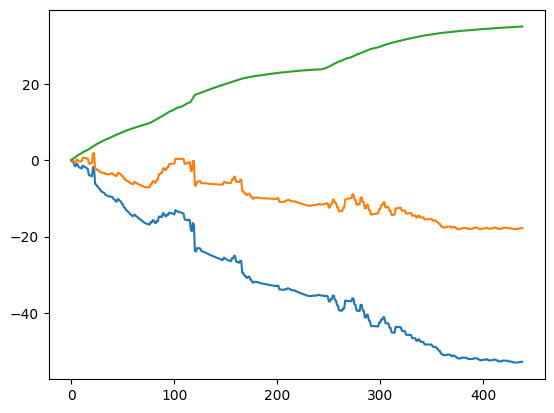

In [105]:
plt.plot(trades["pnl"])
plt.plot(trades["agg_pnl"])
plt.plot(trades["agg_commission"])
plt.show()